# Machine Learning

There are some tasks where a machine can perform better eg: calculations, and some task a human can perform better than a machine eg: riding or conversations. 

**Machine Learning** is a domain where we teach machine to learn from data and find patterns on their own.

Although Machine Learning is a broader term which encompasses topics like deep learning, we this discuss topics from basics to advanced level.

## Types of Machine Learning

1. Supervised - We give labelled data ->  **Classification**, **Regression** 
2. Unsupervised - We give unlabelled data ->  **Clustering**, **Association**

## Linear Regression 

We try to fit a line through all the data points, ensuring that the line will have the least average error. Using the line as a reference we predict the value for any given input.

Lets look at how it works with example

### Using Single variable 

Task: Predict Income based on year <br>
use the csv file: canada_per_capita_income, to train a model and prdict income

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import linear_model

In [3]:
# load the file to pandas data frame

df = pd.read_csv("canada_per_capita_income.csv")
df.columns = ["year", "income"]

df.head()

,year,income
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


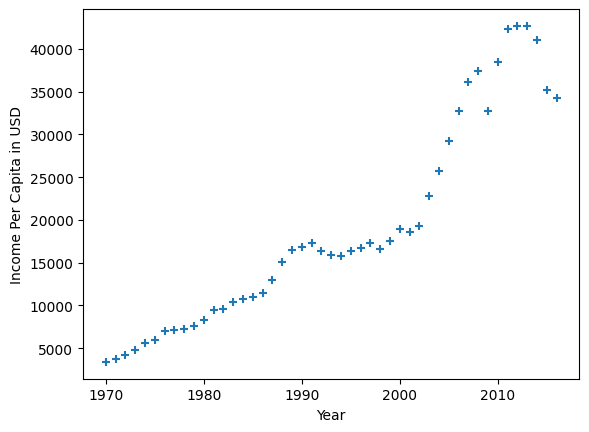

In [4]:
%matplotlib inline
plt.xlabel("Year")
plt.ylabel("Income Per Capita in USD")
plt.scatter( df.year, df.income,  marker="+")

Let us now fit a line using Linear Regression

In [5]:
reg = linear_model.LinearRegression()
reg.fit(df[['year']], df.income)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[828.47]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.632e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Let us now predict income for any year

In [6]:
reg.predict([[2016]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([37974.83379353])

Let us see the line using plot

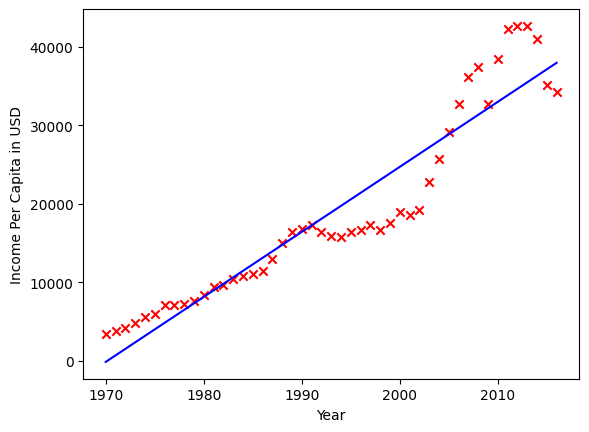

In [7]:
%matplotlib inline

plt.xlabel("Year")
plt.ylabel("Income Per Capita in USD")
plt.scatter( df.year, df.income, color="red", marker="x")
plt.plot(df.year, reg.predict(df[['year']]), color="blue")



### Multiple Variable or Multivariate Regression

In single variable model, we only had one feature ,i.e year, which is also called as independent variable. 
Now we will look at an example of mutiple vairables.
The file hiring.csv contains some data

In [8]:
df = pd.read_csv("hiring.csv")
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


Take a look at the data, we have 3 features, independent vaiables and 1 dependent variable(salary). Lets build a model that will predict the salary based on this little data.

**Step 1.** Data Preprocessing - we first need to clean the data -> handle missing data. Also our model takes only numericals as input hence we will have to convert the experience from string to integer.

In [9]:
#fill all N/As with zero
df.experience = df.experience.fillna("zero")    

In [10]:
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [11]:
# we can use this library to converth str to int
from word2number import w2n
# eg 
print(w2n.word_to_num("twenty"))


20


In [12]:
df.experience = df.experience.apply(w2n.word_to_num)


In [13]:
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000


If we notice, the columns names are too long for use to type - lazy - let us rename them

In [14]:
df.columns = ["experience", "test_score", "interview_score", "salary" ]
df.head(10)

,experience,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,NaN,7,72000
7,11,7.0,8,80000


The experience columns has a NaN val - lets us fix that

In [15]:
# lets fill that NaN with median values
import math

median_test_score = math.floor(df["test_score"].median())
median_test_score

8

In [16]:
df.test_score = df.test_score.fillna(median_test_score)
df.head(10)

,experience,test_score,interview_score,salary
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


Now **Step 1** is Complete <br>
Let us now build a model

In [17]:
reg = linear_model.LinearRegression()
reg.fit(df[["experience", "test_score", "interview_score"]], df.salary)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[2812.95,1845.71,2205.24]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['experience','test_score','interview_score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.774e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


Now we can predict the values.

lets predict salary of two cases - <br>
2 yr experience, 9 test score, 6 interview score

12 yr experience, 10 test score, 10 interview score

In [18]:
reg.predict([[2, 9, 6]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53205.96797671])

In [19]:
reg.predict([[12, 10, 10]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92002.18340611])

**How does the model find the best fit line?**

The simplest explanation is using the slope of the line `y = mX = b`, where m and b are independent variable and X is the value which we will predict, we find a value for Slope and compare the distances of each point v/s the line and square them (to account for negatives and to make things more precise) this is called squared error, after this we divide this value by the total number of points which we compared **n** -> this is know as **Mean Squared Error** and this is one the cost function -> we try to minimze the cost function, basically - the lower the cost the better the fit.

**How do we find the lowest cost for this?** using Graient Descent(Learn more about it personally). Here we will only implement the function.

In [20]:
def gradient_descent(x, y):
    n = len(x)
    iterations = 1000
    learning_rate = 0.1  # Fast learning rate works now!
    m_curr = b_curr = 0.0
    old_cost = float('inf')

    # Feature Scaling (Z-score normalization)
    x_scaled = (x - np.mean(x)) / np.std(x)
    y_scaled = (y - np.mean(y)) / np.std(y)

    for i in range(iterations):
        y_predicted = m_curr * x_scaled + b_curr
        cost = np.mean((y_scaled - y_predicted) ** 2)
        
        md = -(2/n) * np.sum(x_scaled * (y_scaled - y_predicted))
        bd = -(2/n) * np.sum(y_scaled - y_predicted)
        
        m_curr -= learning_rate * md
        b_curr -= learning_rate * bd
        
        if abs(old_cost - cost) < 1e-7:
            print(f"Converged smoothly at iteration {i}!")
            print(f"Scaled Parameters -> m: {m_curr:.4f}, b: {b_curr:.4f}, cost: {cost:.6f}")
            break
            
        old_cost = cost

df = pd.read_csv("test_scores.csv")
x = df["math"].to_numpy()
y = df["cs"].to_numpy()

gradient_descent(x, y)

Converged smoothly at iteration 35!
Scaled Parameters -> m: 0.9479, b: -0.0000, cost: 0.100944


**Steps in Machine Learning** - Training, Testing and  predicting - We took very small datasets to train our models and it basically got the result in an instant. However, in real scenario the datasets are huge and training a model can take significant amount of time and once we train and test our model, if it works fine, we would want save our model and use it whenever we want need it.

Let us first train a model:

In [21]:
df = pd.read_csv("canada_per_capita_income.csv")
df


,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [22]:
current_model = linear_model.LinearRegression()
current_model.fit(df[["year"]]  , df["per capita income (US$)"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[828.47]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.632e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [23]:
current_model.predict([[2002]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26376.32274041])




## Saving Models

We will use 2 different methods to save a model:
1. Pickle
2. joblib

**using pickle**

In [24]:
import pickle

with open("stored_model_with_pickle", "wb") as f:
    pickle.dump(current_model, f)  # "current_model" will be stored in a file "stored_model_with_pickle"

In [25]:
# now to use the stored model
with open("stored_model_with_pickle", "rb") as f:
    saved_pickle_model = pickle.load(f)

saved_pickle_model.predict([[2002]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26376.32274041])

As we can see, we success fully saved the model into a file and accessed it, our predicted value for both we same

**Using JobLib**

In [26]:
import joblib

joblib.dump(current_model, "stored_model_with_joblib")



['stored_model_with_joblib']

In [27]:
saved_joblib_model = joblib.load("stored_model_with_joblib")

In [28]:
saved_joblib_model.predict([[2002]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26376.32274041])

As simple as that.

 joblib performs better when large numpy arrays are used

## One Hot Encoding

Look at the dataset we have below

In [29]:
df = pd.read_csv("carprices.csv")
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


The column *Car Model* has Catergorical Data, but our model only works with Numerical Data.
<br>How can we turn this into numerical data?<br>
Maybe we can treat BMW as 1, Audi as 2, and Benz as 3 ? No. if we do that our model may interpret the data in the wrong way and give rank them or it might treat 1 as lower value and 3 as higher.

This is where the concept of **One Hot Encoding** comes into play.<br>
*One-hot encoding is a data preprocessing technique that converts categorical text data into a binary numeric format (0s and 1s).* - how does it work?

In [30]:
df = pd.get_dummies(df, columns=['Car Model'])
df

,Mileage,Sell Price($),Age(yrs),Car Model_Audi A5,Car Model_BMW X5,Car Model_Mercedez Benz C class
0,69000,18000,6,False,True,False
1,35000,34000,3,False,True,False
2,57000,26100,5,False,True,False
3,22500,40000,2,False,True,False
4,46000,31500,4,False,True,False
5,59000,29400,5,True,False,False
6,52000,32000,5,True,False,False
7,72000,19300,6,True,False,False
8,91000,12000,8,True,False,False
9,67000,22000,6,False,False,True


If you look carefully - all the rows that had BMW will have 1s(True), *i.e  one hot*, in the BMW columns and the rest columns will be false, called as **Dummy Variables**, similary for the other two brands.

This will avoid the problem of giving wrong meaning/rank to the data. However, can you find the problem with this? What if we have 1k different brands or a column of pincodes or cities? It will require massive memory and high dimentions.

Do we actually need 3 coulumns to know the brand? Can we do it with lesser? YES! with 2, we can know the value of third by looking at the rest two, eg: if both are 0 then 3rd will be 1, else 3rd will be 0. This can reduce redundancy and solve a bigger problem known as the **Dummy varaible Trap** - so some detailed research about it.


Hence, we drop any one of the 3 categories

In [31]:
dropped_df = df.drop("Car Model_Mercedez Benz C class", axis="columns")
dropped_df

,Mileage,Sell Price($),Age(yrs),Car Model_Audi A5,Car Model_BMW X5
0,69000,18000,6,False,True
1,35000,34000,3,False,True
2,57000,26100,5,False,True
3,22500,40000,2,False,True
4,46000,31500,4,False,True
5,59000,29400,5,True,False
6,52000,32000,5,True,False
7,72000,19300,6,True,False
8,91000,12000,8,True,False
9,67000,22000,6,False,False


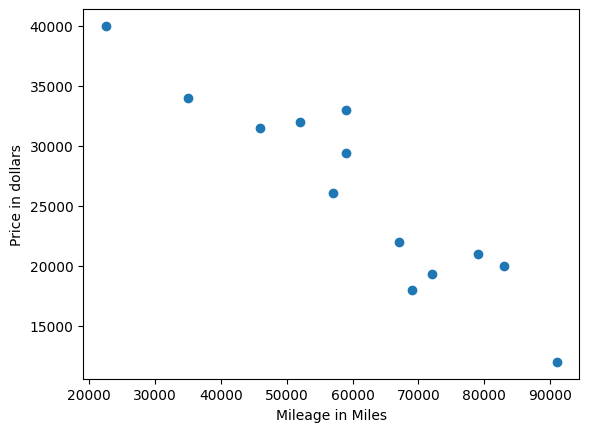

In [32]:
# lets plot mileage vs sell prive to see relationship

%matplotlib inline
plt.xlabel("Mileage in Miles")
plt.ylabel("Price in dollars")
plt.scatter(dropped_df.Mileage, dropped_df["Sell Price($)"])

The relation seems resonably linear, lets fit a linear model

In [33]:
X = dropped_df.drop("Sell Price($)", axis="columns")
X # this are our independent variables

,Mileage,Age(yrs),Car Model_Audi A5,Car Model_BMW X5
0,69000,6,False,True
1,35000,3,False,True
2,57000,5,False,True
3,22500,2,False,True
4,46000,4,False,True
5,59000,5,True,False
6,52000,5,True,False
7,72000,6,True,False
8,91000,8,True,False
9,67000,6,False,False


In [34]:
Y = dropped_df["Sell Price($)"]
Y # this is our dependent variable (to predict)

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

In [35]:
lm = linear_model.LinearRegression()
lm.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ -0.37,-1332.45,-2453.54,-6738.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Mileage','Age(yrs)','Car Model_Audi A5','Car Model_BMW X5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.898e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [36]:
lm.predict([[45000, 4, 0, 0]])

C:\Users\saads\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36991.31721061])

How do we know how accurate our model is?

In [37]:
lm.score(X, Y)

0.9417050937281082

## Train Test Split:

Ideally we should never use all of our real world dataset to train our model, how will we test the accuracy reliably if we use all the data to train the model? We should preserve some percentage of dataset, say 20%, and train the model with 80% of the dataset. This way we will be able to use the leftover 20% data (which our model has not seen yet) to test if the accuracy is good because when we deploy the model in real world, chances are, the data which our model will process will be unique - which was not seen during training.

Doing this will give us the better TRUE idea of how our model will perform, although there is never a 100% guarentee in this domain.

In [38]:
# lets make a simple dataframe 
df = pd.read_csv("carprices.csv")
df = df.drop(["Car Model" , "Age(yrs)"], axis="columns")
df

,Mileage,Sell Price($)
0,69000,18000
1,35000,34000
2,57000,26100
3,22500,40000
4,46000,31500
5,59000,29400
6,52000,32000
7,72000,19300
8,91000,12000
9,67000,22000


In [39]:
# Let us assign independent variables(X)

X = df[["Mileage"]]
X

,Mileage
0,69000
1,35000
2,57000
3,22500
4,46000
5,59000
6,52000
7,72000
8,91000
9,67000


In [40]:
# Let us assign dependent variables(Y)

Y = df["Sell Price($)"]
Y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

Lets us split our data into 80% train and 20% split.

In [41]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20) # 20% test

x_train

,Mileage
3,22500
4,46000
7,72000
5,59000
0,69000
1,35000
8,91000
11,79000
2,57000
10,83000


As you can see - function splits the data into 80/20 and will shuffle the data.

You can call the function again and it will keep shuffling ranodomly

In [42]:
x_train, x_test, y_train, y_test= train_test_split(X, Y, test_size=0.20) # 20% test
x_train

,Mileage
5,59000
7,72000
10,83000
6,52000
1,35000
2,57000
0,69000
8,91000
9,67000
12,59000


If we want to have a same output(reproducible output) - we can use the "random state" attribute 

In [43]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=20) # random state
x_train

,Mileage
5,59000
0,69000
2,57000
6,52000
12,59000
4,46000
9,67000
11,79000
10,83000
3,22500


In [44]:
x_train, x_test, y_train, y_test= train_test_split(X, Y, test_size=0.20, random_state=20) # random state
x_train

,Mileage
5,59000
0,69000
2,57000
6,52000
12,59000
4,46000
9,67000
11,79000
10,83000
3,22500


Using random_state we can ensure we will have same output

In [45]:
# let us create our linear regression model
lr = linear_model.LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.37]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Mileage']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.901e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Model Successfully trained on our train data - which was 80%, now we have 20% of the dataset - x_test, y_test.

So, basic structure is that we give X and the model predicts Y - perfect?

We know the values of both x and y, but our model has not seen the values of x and y (20% test data), so we will ask our model to predict the output (Y_test) for the given input (X_test), and we will compare the models output with our Y_test (which is the actualy output) to determine the accuracy of our model

In [46]:
lr.predict(x_test)

array([22671.96554061, 36208.50901867, 15720.76753836])

In [47]:
y_test

7    19300
1    34000
8    12000
Name: Sell Price($), dtype: int64

As you can notice the values are not 100% same but falls within some range our of actual output. 

Rather than calculation the accuracy manually we can use the follwing method

In [48]:
lr.score(x_test, y_test)

0.8801729216313101

This basically means our model is 88% accurate.

What are all the different steps you can take to improve our models efficiency? (self-study)

## Regression v/s Classification
In the previous model, we predictic prices i.e Numerical Values, and our output was Numerical Data. The models which predicts continious numbers are called as **Regression Models**.

What if we want to predict wheather a mail is Spam or No-Spam - any one of two categories OR any other categorical data? We will Use **Classificaton Models**

### Types of Classification - based on the number of categories:
1. Binary Classification - only two categories, eg: Yes or NO, Spam or No spam, etc
2. Muticlass Classification - 2 or more categories.

## Logistic Regression

In this section we will learn about another model called as Logistic Regression. Contary to its name, Logistic Regression is actually an classification model and not a regression model.

The reason it's name include regression is beacause of how it work internally and not beacause of it's output. Internally, it works same as a regression model and predicts a contionoius value between 0 and 1, and based on a threshold or manual cutoff (eg 0.5) it will either output category 0 or 1.

Logistic Regression is most commonly used for Binary Classification(2 catergories). However, it is not limited to it and can be adapted for datasets with 3 or more catagories - It uses nested logic to decide the winner (eg : 1 vs 2, then 2 vs 3, then winner of both competes to decide the final output)

### Binary Classification



This time we will work with a larger datast

In [49]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


So this dataset has 10 cols and each of them has 14,999 rows, some of which are float and strings but rest and integer

Let's try to figure out variables have direct impact on employee retention "left" variable

In [51]:
only_numeric = df.drop(["Department", "salary"], axis="columns")
only_numeric.groupby("left").mean()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


left = 0 = Not left
left = 1 = left

We can see differences in following:
1. satisfaction_level - 0.44 vs 0. 66 - less satisfaction corresponds to left
2. average_monthly_hours - 201 vs 199 - higher monthy hours worked also shows a cause
3. promotion_last_5years - 0.005 vs 0,02 = less promotion corresponds to left

<Axes: xlabel='salary'>

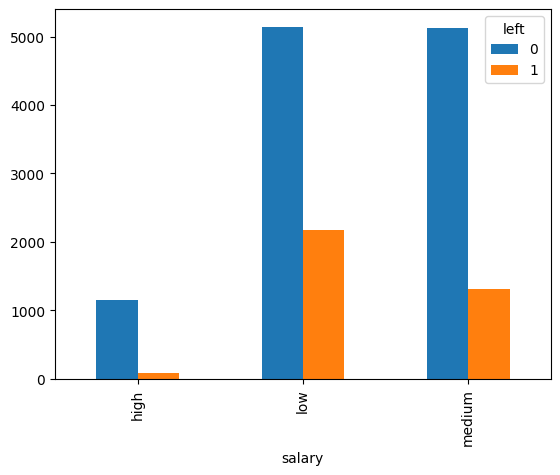

In [52]:
# Find the impact of Salary on employee retention
pd.crosstab(df["salary"], df["left"]).plot(kind="bar")

Higher salaries mean employs do not leave, low salary has higher rate of "left"

<Axes: xlabel='Department'>

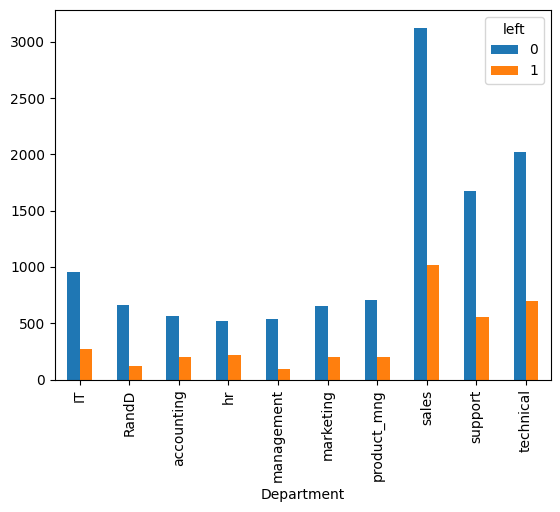

In [53]:
# impact of Department and Employee Retention
pd.crosstab(df.Department, df.left).plot(kind="bar")

management department has lowest "left" but no particular patterns overall 

Let us build a logistic model using the colums where we found the most impact i.e satisfaciton level, monthly average hours, promotion and salary

In [54]:
# Our salary is a categorical data. What shall we do? one hot encoding!
df = pd.get_dummies(df, columns=["salary"])

In [55]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,sales,False,True,False
1,0.80,0.86,5,262,6,0,1,0,sales,False,False,True
2,0.11,0.88,7,272,4,0,1,0,sales,False,False,True
3,0.72,0.87,5,223,5,0,1,0,sales,False,True,False
4,0.37,0.52,2,159,3,0,1,0,sales,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,False,True,False
14995,0.37,0.48,2,160,3,0,1,0,support,False,True,False
14996,0.37,0.53,2,143,3,0,1,0,support,False,True,False
14997,0.11,0.96,6,280,4,0,1,0,support,False,True,False


In [56]:
# Letsl drop all one encoded and rest of all unrequired coulums

X = df.drop(["last_evaluation", "number_project", "time_spend_company", "Work_accident", "left", "Department", "salary_medium"], axis="columns")
X

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low
0,0.38,157,0,False,True
1,0.80,262,0,False,False
2,0.11,272,0,False,False
3,0.72,223,0,False,True
4,0.37,159,0,False,True
...,...,...,...,...,...
14994,0.40,151,0,False,True
14995,0.37,160,0,False,True
14996,0.37,143,0,False,True
14997,0.11,280,0,False,True


In [57]:
y = df.left
y

0        1
1        1
2        1
3        1
4        1
        ..
14994    1
14995    1
14996    1
14997    1
14998    1
Name: left, Length: 14999, dtype: int64

In [58]:
# let us now split the data into  train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10) 

In [59]:
# now train the Logistic Model
from sklearn.linear_model import LogisticRegression

logR = LogisticRegression()

logR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [60]:
logR.predict(X_test)

array([0, 0, 0, ..., 1, 0, 0], shape=(3000,))

In [61]:
logR.score(X_test, y_test)

0.7706666666666667

Our model is 77% accurate

### Muticlass Classification

Check out notes (in `main.ipynb`) in the follwing two repositories where i have created these models
1. Digit Recogniton [repository](https://github.com/Saad-SYEDK/Digit_Recognition).
2. Iris flower [repository](https://github.com/Saad-SYEDK/iris_flower).

## Decision Tree

A supervised Machine Learning algorithm used for both classification and regression. It works like a flowchart/up-side down tree that splits data into smaller subsets based on specific conditions

In [62]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We have to predict Survived based on Pclass, sex, age, fare.

In [63]:
df = df.drop(["PassengerId", "Name", "SibSp", "Parch", "Ticket", "Cabin", "Embarked"], axis="columns")

In [64]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [65]:
X = df.drop(["Survived"], axis="columns")
X

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500
...,...,...,...,...
886,2,male,27.0,13.0000
887,1,female,19.0,30.0000
888,3,female,NaN,23.4500
889,1,male,26.0,30.0000


Is this above data good? no, there are few problems, 1. We hvae one non-numerical columns and 2. We can see an NaN value. Lets fix that.

In [66]:
X['Age'] = X['Age'].fillna(df.Age.mean())
X

,Pclass,Sex,Age,Fare
0,3,male,22.000000,7.2500
1,1,female,38.000000,71.2833
2,3,female,26.000000,7.9250
3,1,female,35.000000,53.1000
4,3,male,35.000000,8.0500
...,...,...,...,...
886,2,male,27.000000,13.0000
887,1,female,19.000000,30.0000
888,3,female,29.699118,23.4500
889,1,male,26.000000,30.0000


Now lets change the "Sex" columns to numeric using dummy variables

In [67]:
X = pd.get_dummies(X, columns=["Sex"])

In [68]:
X

,Pclass,Age,Fare,Sex_female,Sex_male
0,3,22.000000,7.2500,False,True
1,1,38.000000,71.2833,True,False
2,3,26.000000,7.9250,True,False
3,1,35.000000,53.1000,True,False
4,3,35.000000,8.0500,False,True
...,...,...,...,...,...
886,2,27.000000,13.0000,False,True
887,1,19.000000,30.0000,True,False
888,3,29.699118,23.4500,True,False
889,1,26.000000,30.0000,False,True


Let us remove one column to avoid dummy variable trap

In [69]:
X = X.drop(["Sex_female"], axis="columns")

In [70]:
X

,Pclass,Age,Fare,Sex_male
0,3,22.000000,7.2500,True
1,1,38.000000,71.2833,False
2,3,26.000000,7.9250,False
3,1,35.000000,53.1000,False
4,3,35.000000,8.0500,True
...,...,...,...,...
886,2,27.000000,13.0000,True
887,1,19.000000,30.0000,False
888,3,29.699118,23.4500,False
889,1,26.000000,30.0000,True


Now our data is clean enough to train our model

In [71]:
y = df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

Let us split data for train and test

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [73]:
from sklearn import tree

dt = tree.DecisionTreeClassifier()

In [74]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [75]:
dt.score(X_test, y_test)

0.7932960893854749

So our model is 80% accurate

## Support Vector Machine (SVM)

SVM is a supervised machine learning algorithm used for classification, regression, and outlier detection.

**Working:**

It finds the best decision boundary between data points of different classes - this boundary is called as hyperplane. This can work in N-dimentions.

The data points closest to the *Hyperplane* are called as support vectors - they help define the position and orientation of the boundary.

The distance between the hyperplane and the support vector is called **Margin** - the algorithms tries to maximize the margin as much as possible to ensure better accuracy on newer datapoints. 

The boundary can be **linear** or **non-linear** - this can be done using `kernel` parameter.

the margin can either be **hard** - perfect separaton with no errors, or **Soft** - allows for some erros using regularization parameters. *hard* margin can cause overfitting in some cases.



In [76]:
from sklearn.svm import SVC

In [77]:
# we will use digits dataset from sklearn for this 

from sklearn.datasets import load_digits

df = load_digits()
print(df.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [78]:
dir(df)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [79]:
len(df.data[0])

64

this is a 1d representation of 8x8 image

In [80]:
df.target[0]

np.int64(0)

df.data is dependent variable and df.target is independent variable

In [81]:
X = df.data
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [82]:
y = df.target
y

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

Lets us split the data into train/test

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [84]:
sc = SVC()

In [85]:
sc.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [86]:
sc.score(X_test, y_test)

0.9833333333333333

Our model is 98% accurate

## Random Forest

What is a forest? A forest has many *trees* and ....!

It is an Supervised machine learning algorithm used for classification and regression. It builds a "forest" of multiple Decision Trees to make more accurate and stable predictions.

Random Forest belongs to a category machine learning called as **Ensemble Learning** - combining output of several individual models to deliver a single superior result.

**Problem with decision trees** - a single decision tree is highly sensitve to the specific data it has been trained on - it tends to memorize the training data, which leads to **overfitting**(high variance). Random forest solves this by combining multiple different DTs, the errors of each average out, leading to a highly accurate and reliable generalizations

**The random factor**: the main feature of random forest is that it forces each decision tree to be unique using two distinct layers -
1. Random sampling (Bagging) - each tree gets a subset of the original data **randomly with replacement** - meaning a particular row might be picked multiple times
2. Random feature selection - every time a tree node splits to make a decision rule, it won't be allowed to look at all the features. Instead, it chooses a random subset of features(usaully square root of total number of features). This ensures that the tree does not look at all the features to learn the same pattern.

**Final Decision**: Once we have got the output of all the trees (we basically now have an entire forest), we can either choose :
1.  Majority decision/Voting - for classificaiton
2.  Average of all outputs - for regression



In [87]:
# let us demonstrate this on iris_flower dataset from sklearn
from sklearn.datasets import load_iris

In [88]:
df = load_iris()

In [89]:
dir(df)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [90]:
df.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [91]:
# same as above "data" is our independent variable and target is our dependent variable.

X = df.data
y = df.target 

In [92]:
# split into train/set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [93]:
# load our model 

from sklearn.ensemble import RandomForestClassifier

rc = RandomForestClassifier()
rc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [94]:
rc.score(X_test, y_test)

0.9333333333333333

our model has 93% accuracy

Let us see how we can tune our model

In [95]:
our_model = RandomForestClassifier(n_estimators=500) # this is known as "Hyperparameter tuning"
our_model.fit(X_train, y_train)
our_model.score(X_test, y_test)

0.9666666666666667

by we were able to achieve better accuracy

Let us plot a heatmap

In [96]:
y_predicted = our_model.predict(X_test)

from sklearn.metrics import confusion_matrix

cm  = confusion_matrix(y_test, y_predicted)
cm

array([[12,  0,  0],
       [ 0,  8,  1],
       [ 0,  0,  9]])

Text(50.722222222222214, 0.5, 'Actual')

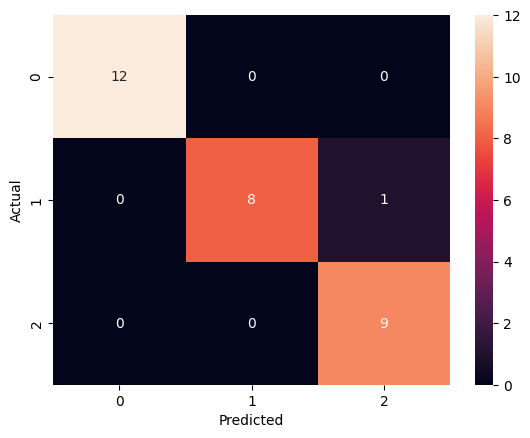

In [97]:
import  seaborn as sn
%matplotlib inline
sn.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")



## K-Fold cross-validation

Till now we have been using train/test split to test(validate) our models. Is that the best? what if by-chance our data got split in a way that the train split has excluded one type of output and never learned it, so when we test our model we get bad result.

also train/test split randomly splits the data, what if our data has a data-point which rarely comes-up and it got missed out from the training set.

Solution to avoid this luck/chance factor? **K-Fold cross-validation**

It splits the data into 'K' equal-sized, non-overlapping parts/subsets(called as folds). After this K-1 folds are used for training as 1 for testing, this is repeated K times and each time with unique fold for testing. The scores of K-iterations are averaged, this gives us a highly reliable estimate of how our model will perform.




Common Types of K-Folds :
1. **Stratified K-Fold** : ensures all different classes in each folds remain in same proportion as they are in complete dataset, important for imbalanced dataset
2. **Repeated K-Fold :** Once k-iteration are finished, the complete dataset is shuffled and the whole process is repeated again multiple times - even higher reliability 
3. **Leave one out cross validation (LOOCV) :** a case where our K = n, where n is the total number of datapoints(rows) - rarely used cuz it has high computational overhead 


Let us try this with iris-flower database from sklearn

In [98]:
df = load_iris()

# we know our X and y

X, y = df.data, df.target

In [99]:
# let us load any model, we will use random forest

our_model = RandomForestClassifier()

In [100]:
# let us train and test our model

# Fortunately - sklearn has functions that does the K-fold split and validate for us

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GroupKFold
# the above are different variations of K-fold - each with its own mechanism

# we can use the below method to directly validate 
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=11)

# if our data is ordered in anyway, we must set shuffle=True else our evaluation will be ruined

our_score = cross_val_score(our_model, X, y, cv=kf)

In [101]:
our_score

array([0.86666667, 1.        , 0.86666667, 0.93333333, 1.        ,
       1.        , 1.        , 1.        , 0.93333333, 0.93333333])

This is our score for K different scores- as we can see there are some variations which were caused by the "Chance-factor" cuz of random splitting, we can ensure reliability by taking average of all this

In [102]:
our_score.mean()

np.float64(0.9533333333333334)

## K-Means Clustering

It is an unsupervised machine learning algorithm.

It groups raw, unlabelled data into 'K' non-overlapping, distinct clusters based on similarity.

**Working :**
1. choose number of clusters (K)- one way is to use *Elbow method*
2. Initialize centroids - K centroids(centers) are randomly placed in the data space
3. Assignment - calculate the distance (ex: euclidian distance) from each point to the centroids and assign them to the closest centroid.
4. update centroids - calculate the average of all the points of each centroid and update the centroid position.
5. repeat from step 3 until the centroids no longer move.

In [103]:
# let us use our iris_flower data set
df = load_iris()


In [104]:
df.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

 as we can see we have 3 distinct targets, so ideally we should have 3 clusters - but we will use the "elbow method" to determine the number of clusters

In [105]:
X, y = df.data , df.target
df.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [106]:
df.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

Let us plot a scatter plot to see how our data looks

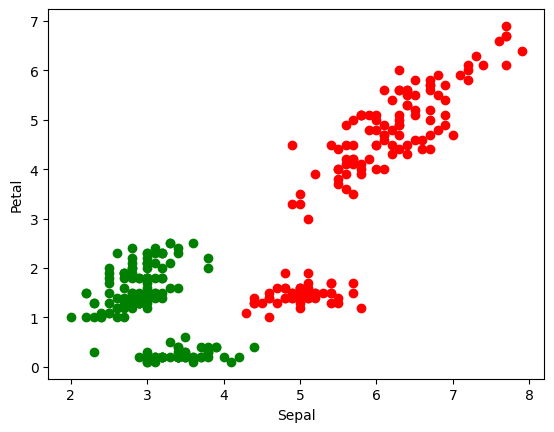

In [107]:
%matplotlib inline
for i in range(len(X)):
    plt.scatter(X[i][0], X[i][2], color="red")
    plt.scatter(X[i][1], X[i][3], color="green")
    
plt.xlabel("Sepal")
plt.ylabel("Petal")
        
    # 2. Define your manual legend entries
# legend_handles = [
# mpatches.Patch(color="red", label="length"),
# mpatches.Patch(color="green", label="width")
# ]

# # 3. Pass the custom handles directly to the legend
# plt.legend(handles=legend_handles)
plt.show()

as we can notice there are clustes of our data which mans thre are some similarities or relation between different features which can help us predict the output.

Our data has multiple dimentions (i.e 4d -> petal/sepal x lenght/width) and unlike 2d data like (age X weight or experience X income, etc) it is difficult to visualize it and understand the relationship between each features,

different ways to visualize this are:

let us create an dataframe of X

In [108]:
columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
X_df = pd.DataFrame(X, columns=columns)

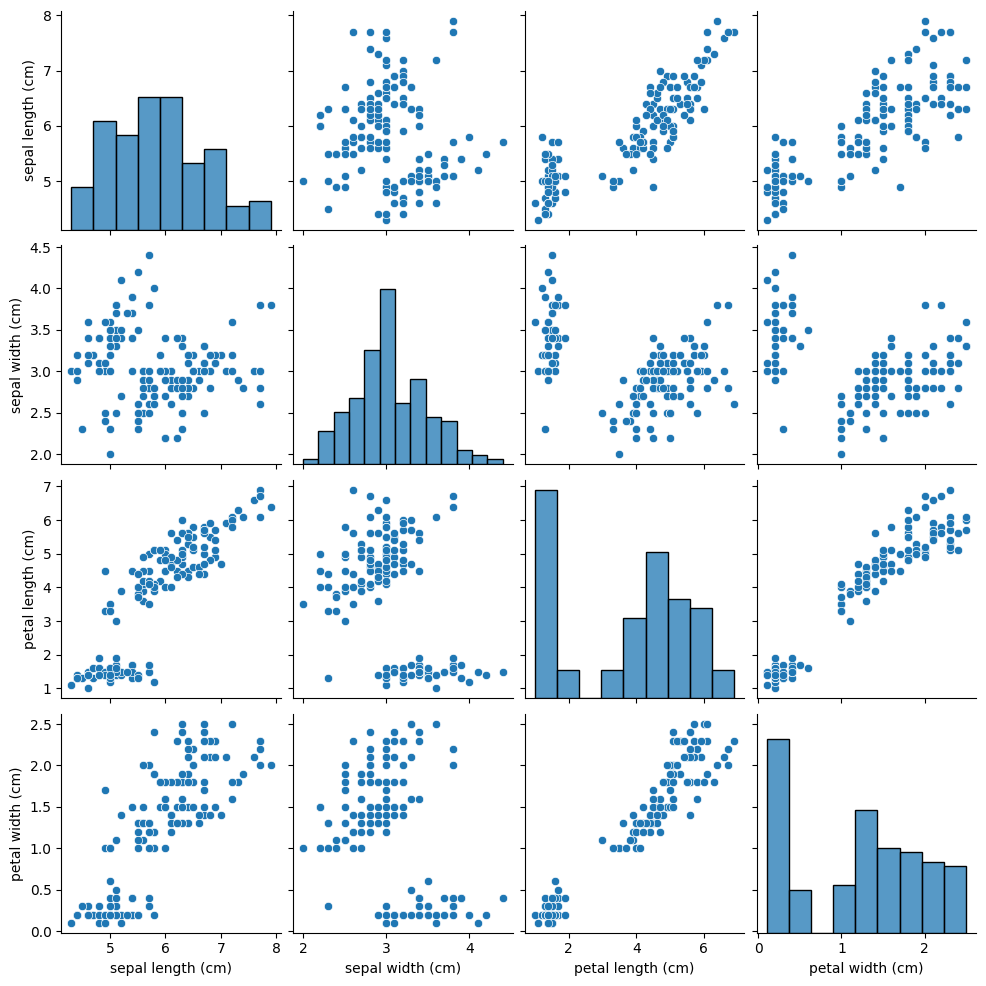

In [109]:
import seaborn as sns
sns.pairplot(X_df) 
plt.show()

this shows the relation between each features 

In [110]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(X)
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

We can actually look where our final centroids are

In [111]:
km.cluster_centers_

array([[5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

as we can see the coordinates are for 4d, not just x,y as we see in 2d

let us compare predicted values vs actual value

let us try to visualize this 

In [112]:
# add the corrsponding cluster
X_df['cluster'] = y_predicted 

# separe dataframes by clusters
df0 = X_df[ X_df.cluster == 0]
df1 = X_df[ X_df.cluster == 1]
df2 = X_df[ X_df.cluster == 2]


let us now plot all in a single scatter plot - we can only plot using 2 features x axis and y axis,

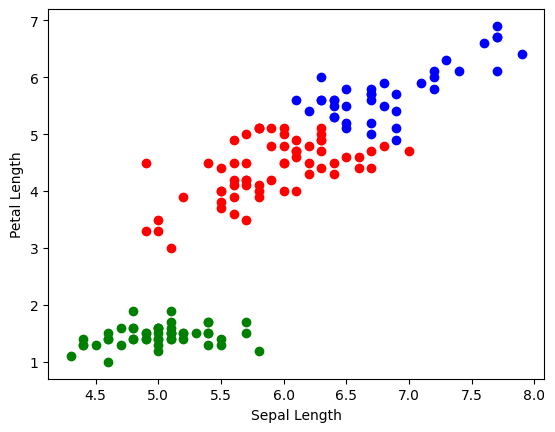

In [113]:
%matplotlib inline

plt.scatter(df0["sepal length (cm)"], df0["petal length (cm)"], color="red")
plt.scatter(df1["sepal length (cm)"], df1["petal length (cm)"], color="green")
plt.scatter(df2["sepal length (cm)"], df2["petal length (cm)"], color="blue")

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.show()

lets us plot same with actual target values

In [114]:
# add the corrsponding cluster
X_df['actual_cluster'] = df.target 

# separe dataframes by clusters
actual_df0 = X_df[ X_df.actual_cluster == 0]
actual_df1 = X_df[ X_df.actual_cluster == 1]
actual_df2 = X_df[ X_df.actual_cluster == 2]

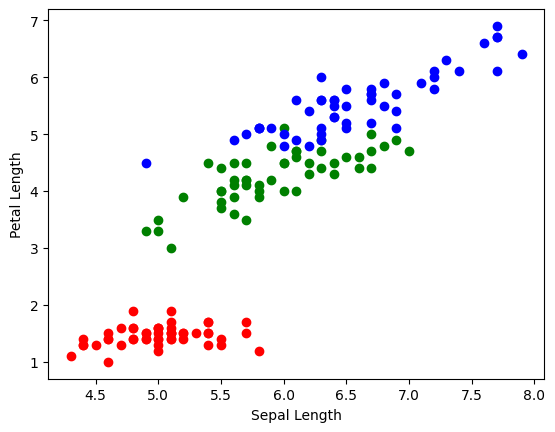

In [115]:
%matplotlib inline

plt.scatter(actual_df0["sepal length (cm)"], actual_df0["petal length (cm)"], color="red")
plt.scatter(actual_df1["sepal length (cm)"], actual_df1["petal length (cm)"], color="green")
plt.scatter(actual_df2["sepal length (cm)"], actual_df2["petal length (cm)"], color="blue")

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.show()

let us do the same with widths 

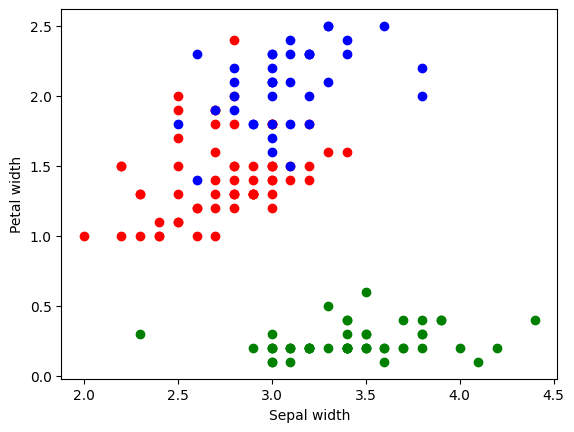

In [116]:
%matplotlib inline

plt.scatter(df0["sepal width (cm)"], df0["petal width (cm)"], color="red")
plt.scatter(df1["sepal width (cm)"], df1["petal width (cm)"], color="green")
plt.scatter(df2["sepal width (cm)"], df2["petal width (cm)"], color="blue")

plt.xlabel("Sepal width")
plt.ylabel("Petal width")

plt.show()

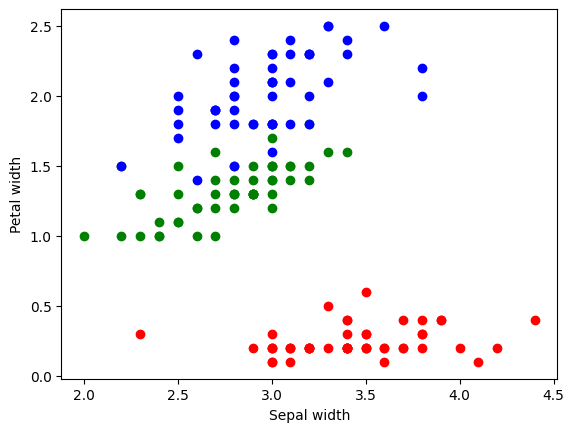

In [117]:
%matplotlib inline

plt.scatter(actual_df0["sepal width (cm)"], actual_df0["petal width (cm)"], color="red")
plt.scatter(actual_df1["sepal width (cm)"], actual_df1["petal width (cm)"], color="green")
plt.scatter(actual_df2["sepal width (cm)"], actual_df2["petal width (cm)"], color="blue")

plt.xlabel("Sepal width")
plt.ylabel("Petal width")

plt.show()

As we can see our the clusters actual target and predicted values seems mostly same. let us compare them directly

In [118]:
X_df[X_df.actual_cluster != X_df.cluster]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster,actual_cluster
0,5.1,3.5,1.4,0.2,1,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,1,0
3,4.6,3.1,1.5,0.2,1,0
4,5.0,3.6,1.4,0.2,1,0
...,...,...,...,...,...,...
133,6.3,2.8,5.1,1.5,0,2
138,6.0,3.0,4.8,1.8,0,2
142,5.8,2.7,5.1,1.9,0,2
146,6.3,2.5,5.0,1.9,0,2


Although our of 150 rows, many rows are not matching directly- this is because the labeling of clusters is done automatically 

Let us now use elbow method to find the ideal clusters for our data.

**Inertia** - when the alrogithm stops it iterations, the sum of sqaured error is calculated using the  distance of each point from final position of the centroid, this is called inertia 

In [131]:
inertia = []
n_clusters = range(1, 10)
for i in n_clusters:
    km = KMeans(n_clusters=i)
    km.fit(X)
    inertia.append(km.inertia_)
inertia

[681.3706,
 152.3479517603579,
 78.851441426146,
 57.25600931571816,
 49.977678460300126,
 41.82786904761906,
 35.02288132553721,
 33.262954036159925,
 28.78577065503409]

Now that we have the inertia for clusters between 1 and 10, we can plot to see where the elbow point is

<function matplotlib.pyplot.show(close=None, block=None)>

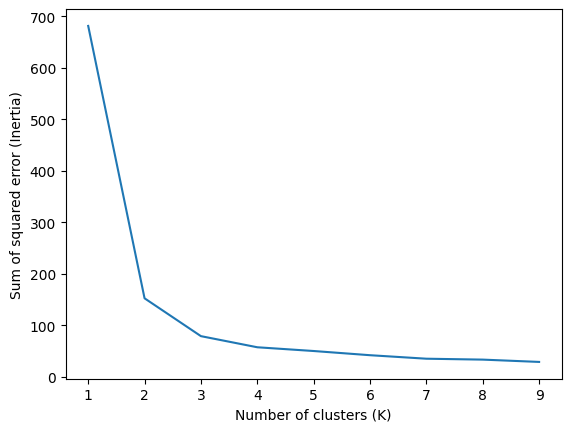

In [132]:
plt.plot(n_clusters, inertia)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Sum of squared error (Inertia)")
plt.show

as we can see after K=3 the decline in inertia is less drastic compared, so we can ideally say the elbow point is 3

## Naives Bayes

It is a supervised machine learning algorithm used for classification. It is based on Bayes-theorem.


## Theory

### Over fitting

### Under fitting

### Variance

### bias

### Bias Vairance trade off

### Regularization

### L1 and L2 penalties

